In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

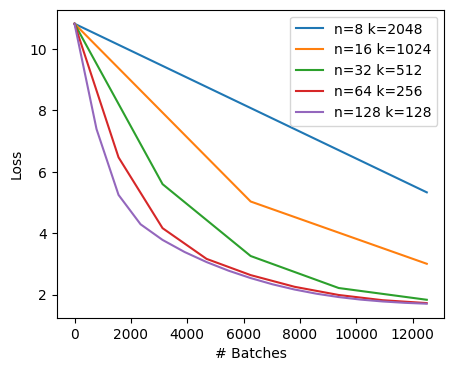

In [33]:
plt.figure(figsize=(5, 4))
for pair in [(8, 2048), (16, 1024), (32, 512), (64, 256), (128, 128)]:
    array_ = []
    for seed in [42, 43, 44]:
        df = pd.read_csv(f'results/n={pair[0]}_k={pair[1]}_seed={seed}/history.csv')
        df = pd.concat([pd.DataFrame({'num_steps': [0], 'val_loss': [np.log(50_000)]}), df])
        array_.append(df['val_loss'])
    plt.plot(df['num_steps'], np.mean(array_, 0), label=f'n={pair[0]} k={pair[1]}')
plt.legend()
plt.xlabel('# Batches')
plt.ylabel('Loss')
plt.show()

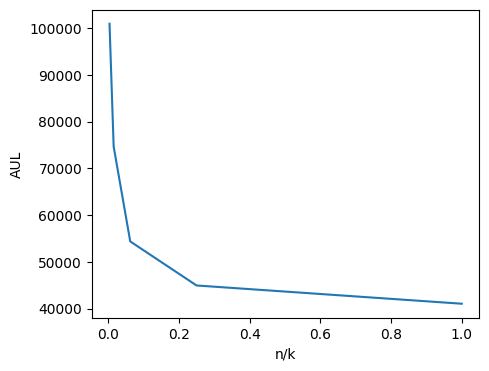

In [37]:
x = []
y = []

plt.figure(figsize=(5, 4))
for pair in [(8, 2048), (16, 1024), (32, 512), (64, 256), (128, 128)]:
    array_ = []
    for seed in [42, 43, 44]:
        df = pd.read_csv(f'results/n={pair[0]}_k={pair[1]}_seed={seed}/history.csv')
        df = pd.concat([pd.DataFrame({'num_steps': [0], 'val_loss': [np.log(50_000)]}), df])
        array_.append(df['val_loss'])

    aul = np.sum((np.mean(array_, 0)[1:]+np.mean(array_, 0)[:-1])/2*(df['num_steps'].diff(1)[1:]))
    y.append(aul)
    x.append(pair[0]/pair[1])

plt.plot(x, y)
plt.xlabel('n/k')
plt.ylabel('AUL')
plt.show()